#Краевая задача
Для решения используем метод конечных разностей и метод Ньютона для линеаризации.Сетка: Разделим отрезок $[0, 1]$ на $N$ интервалов с шагом $h = 1/N$. Точки сетки $x_j = j \cdot h, j=0, \dots, N$.Аппроксимация:Для внутренних точек $j=1, \dots, N-1$:$$F_j(y) = \epsilon \frac{y_{j+1} - 2y_j + y_{j-1}}{h^2} - y_j + y_j^3 = 0$$Матрица Якоби (Якобиан):Элементы трехдиагональной матрицы $J = \frac{\partial F}{\partial y}$:Центральная диагональ: $D_j = -\frac{2\epsilon}{h^2} - 1 + 3y_j^2$Верхняя/нижняя диагонали: $U_j = L_j = \frac{\epsilon}{h^2}$

Eps=0.01, n=2: Сходимость за 6 итераций
Eps=0.001, n=2: Сходимость за 8 итераций
Eps=0.0001, n=2: Сходимость за 4 итераций


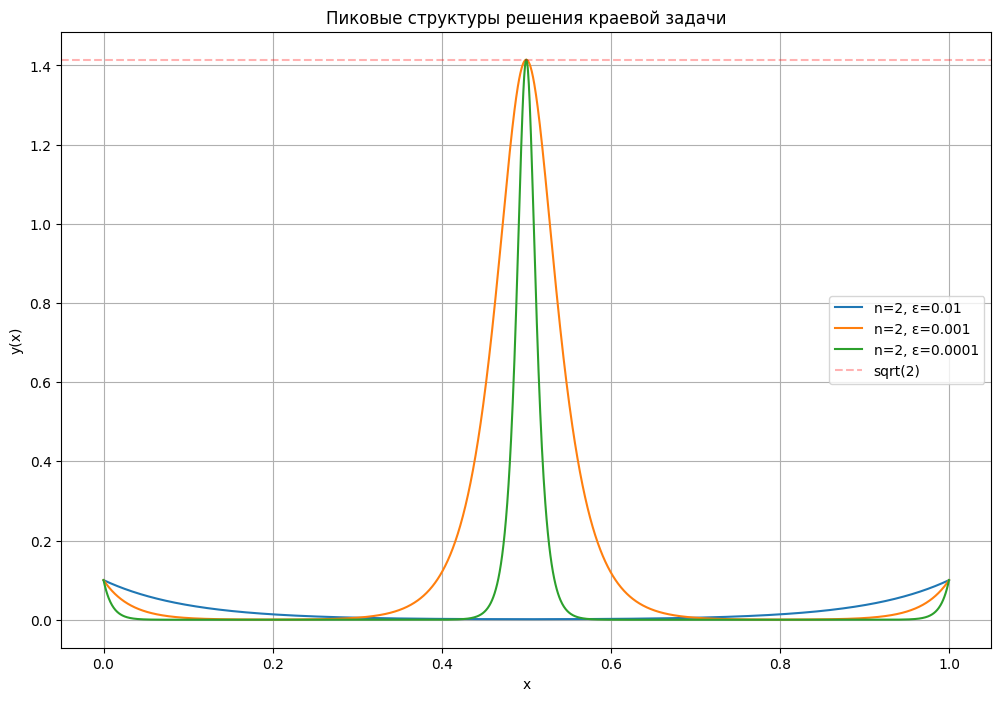

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def solve_bvp_peaks(epsilon, n_peaks, A=0.5, B=0.5, N=1000, max_iter=100, tol=1e-8):
    h = 1.0 / N
    x = np.linspace(0, 1, N + 1)
    
    # 1. Начальное приближение
    # Генерируем "пички" в точках i/n
    y = np.zeros(N + 1)
    y[0], y[-1] = A, B
    for i in range(1, n_peaks):
        peak_pos = i / n_peaks
        # Используем Гауссиану как начальное приближение для пика
        y += np.sqrt(2) * np.exp(-(x - peak_pos)**2 / (2 * 0.01**2))
    
    # Ограничиваем значения для стабильности
    y = np.clip(y, -np.sqrt(2), np.sqrt(2))

    # 2. Метод Ньютона
    for iteration in range(max_iter):
        F = np.zeros(N - 1)
        # Внутренние узлы
        for j in range(1, N):
            idx = j - 1
            y_prev = y[j-1]
            y_curr = y[j]
            y_next = y[j+1]
            F[idx] = epsilon * (y_next - 2*y_curr + y_prev) / h**2 - y_curr + y_curr**3

        # Проверка сходимости
        if np.linalg.norm(F, np.inf) < tol:
            print(f"Eps={epsilon}, n={n_peaks}: Сходимость за {iteration} итераций")
            break

        # Матрица Якоби (в ленточном виде для solve_banded)
        # 0-я строка: верхняя диагональ, 1-я: главная, 2-я: нижняя
        diag_main = -2 * epsilon / h**2 - 1 + 3 * y[1:-1]**2
        diag_side = np.full(N - 2, epsilon / h**2)
        
        ab = np.zeros((3, N - 1))
        ab[0, 1:] = diag_side # верхняя
        ab[1, :] = diag_main   # главная
        ab[2, :-1] = diag_side # нижняя
        
        dy = solve_banded((1, 1), ab, -F)
        y[1:-1] += dy
    else:
        print(f"Внимание: Eps={epsilon}, n={n_peaks} не сошелся!")
        
    return x, y

# Параметры задачи
epsilons = [1e-2, 1e-3, 1e-4]
n_values = [2, 3]
A, B = 0.1, 0.1 # Пример значений границ

plt.figure(figsize=(12, 8))

n=2
for eps in epsilons:
    x, y = solve_bvp_peaks(eps, n, A, B, N=2000)
    plt.plot(x, y, label=f'n={n}, ε={eps}')

plt.axhline(np.sqrt(2), color='r', linestyle='--', alpha=0.3, label='sqrt(2)')
plt.title("Пиковые структуры решения краевой задачи")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True)
plt.show()